# Reading Habits Analysis
This project explores how demographic characteristics such as age, education, and income relate to reading volume and preferences for print, e-book, and audiobook formats.
This analysis is an updated individual version of a university capstone project originally completed with a partner. The original files are still available for reference.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

## Load the Dataset

In [3]:
df = pd.read_csv('reading_habits.csv')

df.head()

,Age,Sex,Race,Marital status?,Education,Employement,Incomes,How many books did you read during last 12months?,Read any printed books during last 12months?,Read any audiobooks during last 12months?,Read any e-books during last 12months?,"Last book you read, you…",Do you happen to read any daily news or newspapers?,Do you happen to read any magazines or journals?
0,66,Male,Refused,Divorced,College graduate,Retired,"$20,000 to under $30,000",97,Yes,No,Yes,Purchased the book,No,Yes
1,46,Male,Native American/American Indian,Married,High school graduate,Employed full-time,"Less than $10,000",97,Yes,Yes,Yes,Purchased the book,Yes,Yes
2,32,Male,Mixed race,Never been married,High school graduate,Employed full-time,"Less than $10,000",97,No,Yes,Yes,Borrowed the book from a friend or family member,Yes,Yes
3,27,Male,Mixed race,Married,High school graduate,Employed full-time,"$40,000 to under $50,000",97,Yes,No,Yes,Borrowed the book from a library,Yes,No
4,16,Female,Mixed race,Never been married,High school incomplete,Employed part-time,"$10,000 to under $20,000",97,Yes,Yes,No,Purchased the book,Yes,No


## Data Overview
Before beginning analysis, I reviewed the dataset's size, column types, missing values, and duplicate records to see what cleaning was needed.

In [4]:
df.shape

(2832, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2832 entries, 0 to 2831
Data columns (total 14 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   Age                                                  2832 non-null   int64 
 1   Sex                                                  2832 non-null   object
 2   Race                                                 2832 non-null   object
 3   Marital status?                                      2832 non-null   object
 4   Education                                            2774 non-null   object
 5   Employement                                          2832 non-null   object
 6   Incomes                                              2832 non-null   object
 7   How many books did you read during last 12months?    2832 non-null   int64 
 8   Read any printed books during last 12months?         2442 non-null   object
 9

In [6]:
df.isnull().sum()

Age                                                      0
Sex                                                      0
Race                                                     0
Marital status?                                          0
Education                                               58
Employement                                              0
Incomes                                                  0
How many books did you read during last 12months?        0
Read any printed books during last 12months?           390
Read any audiobooks during last 12months?              390
Read any e-books during last 12months?                 390
Last book you read, you…                               390
Do you happen to read any daily news or newspapers?      0
Do you happen to read any magazines or journals?         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.columns

Index(['Age', 'Sex', 'Race', 'Marital status?', 'Education', 'Employement',
       'Incomes', 'How many books did you read during last 12months?',
       'Read any printed books during last 12months?',
       'Read any audiobooks during last 12months?',
       'Read any e-books during last 12months?', 'Last book you read, you…',
       'Do you happen to read any daily news or newspapers?',
       'Do you happen to read any magazines or journals?'],
      dtype='object')

## Data Cleaning
To make the dataset easier to work with, I renamed several columns, checked the duplicate record, and investigated missing values.

In [9]:
df = df.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "Race": "race",
    "Marital status?": "marital_status",
    "Education": "education",
    "Employement": "employment",
    "Incomes": "income",
    "How many books did you read during last 12months?": "books_read",
    "Read any printed books during last 12months?": "printed",
    "Read any audiobooks during last 12months?": "audiobook",
    "Read any e-books during last 12months?": "ebook",
    "Last book you read, you…": "last_book_format",
    "Do you happen to read any daily news or newspapers?": "daily_news",
    "Do you happen to read any magazines or journals?": "magazines"
})

In [10]:
df = df.drop_duplicates().copy()

df.shape

(2831, 14)

In [11]:
format_cols = [
    "printed",
    "audiobook",
    "ebook",
    "last_book_format"
]

df[format_cols].isna().all(axis=1).sum()

np.int64(390)

In [12]:
df.loc[
    df[format_cols].isna().all(axis=1),
    "books_read"
].value_counts().sort_index()

books_read
0    390
Name: count, dtype: int64

In [13]:
df["education"].value_counts(dropna=False)

education
High school graduate                                        688
Some college, no 4-year degree                              651
College graduate                                            596
Post-graduate training/professional school after college    501
High school incomplete                                      263
Technical, trade or vocational school AFTER high school      66
NaN                                                          58
Don’t know                                                    8
Name: count, dtype: int64

In [14]:
df.loc[
    df["books_read"] == 0,
    format_cols
] = df.loc[
    df["books_read"] == 0,
    format_cols
].fillna("Not applicable")

In [15]:
df[format_cols].isnull().sum()

printed             0
audiobook           0
ebook               0
last_book_format    0
dtype: int64

In [16]:
df["income"] = df["income"].replace(
    "9$100,000 to under $150,000",
    "$100,000 to under $150,000"
)

In [17]:
df["income"].value_counts()

income
$100,000 to under $150,000    742
$50,000 to under $75,000      394
$75,000 to under $100,000     315
Refused                       291
$30,000 to under $40,000      265
$20,000 to under $30,000      238
$10,000 to under $20,000      216
$40,000 to under $50,000      207
Less than $10,000             163
Name: count, dtype: int64

In [18]:
df["last_book_format"] = df["last_book_format"].replace(
    ["8", "9"],
    "Unspecified"
)

In [19]:
df["last_book_format"].value_counts(dropna=False)

last_book_format
Purchased the book                                  1265
Borrowed the book from a friend or family member     501
Not applicable                                       390
Borrowed the book from a library                     335
Got the book some other way                          309
Unspecified                                           31
Name: count, dtype: int64

### Data Cleaning Summary

The dataset originally contained 2,832 records. One duplicate was removed, leaving 2,831 records for analysis.

The reading-format columns contained 390 missing responses, all belonging to individuals who reported reading 0 books during the previous 12 months. These values were labeled as "Not applicable" rather than removing the records.

A formatting error in the income column was corrected by changing `9$100,000 to under $150,000` to `$100,000 to under $150,000`.

The `last_book_format` column also contained 31 coded responses labeled `8` or `9`. Because their meaning could not be confirmed from the available dataset information, these values were grouped as "Unspecified."

Education contained 58 missing values and 8 "Don’t know" responses. These records were retained in the dataset but will be excluded from analyses that specifically compare education levels.

## Descriptive Statistics
I calculated summary statistics to get a general sense of the participants and their reading behavior before looking at relationships between variables.

In [20]:
df[["age","books_read"]].describe()

,age,books_read
count,2831.000000,2831.000000
mean,47.270223,16.677852
std,18.565806,23.636082
min,16.000000,0.000000
25%,32.000000,2.500000
50%,48.000000,6.000000
75%,62.000000,20.000000
max,93.000000,97.000000


In [21]:
df[[
    "sex",
    "race",
    "education",
    "employment",
    "income"
]].describe(include="object")

,sex,race,education,employment,income
count,2831,2831,2773,2831,2831
unique,2,8,7,8,9
top,Female,White,High school graduate,Employed full-time,"$100,000 to under $150,000"
freq,1479,2216,688,1238,742


In [22]:
avg_age = df.age.mean()
avg_books = df.books_read.mean()
median_books = df.books_read.median()

print(f"Average age: {avg_age:.1f} years")
print(f"Average books read: {avg_books:.1f}")
print(f"Median books read: {median_books:.1f}")

Average age: 47.3 years
Average books read: 16.7
Median books read: 6.0


### Summary
Participants had an average age of 47.3 years. The average number of books read in the last 12 months was 16.7, while the median was only 6 books.
The large differnce between the mean and median suggests that reading volume is right-skewed, with a smaller group of participants reporting much higher number of books read.
The dataset also includes a mix of demographic groups, although some categories are much more common than others. 

## Distribution of Books Read
To better understand overall reading behavior, I examined the distribution of the number of books participants reported reading during the previous 12 months.

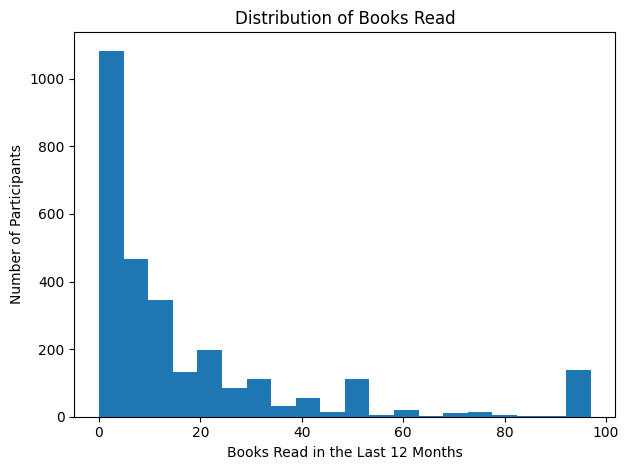

In [23]:
plt.hist(df.books_read, bins=20)

plt.title("Distribution of Books Read")
plt.xlabel("Books Read in the Last 12 Months")
plt.ylabel("Number of Participants")
plt.tight_layout()

plt.show()

In [24]:
print(f"Mean books read: {df['books_read'].mean():.1f}")
print(f"Median books read: {df['books_read'].median():.1f}")
print(f"Participants who read 0 books: {(df['books_read'] == 0).sum()}")
print(f"Share who read 0 books: {(df['books_read'] == 0).mean() * 100:.1f}%")

Mean books read: 16.7
Median books read: 6.0
Participants who read 0 books: 390
Share who read 0 books: 13.8%


In [25]:
max_books = df["books_read"].max()
max_count = (df["books_read"] == max_books).sum()

print(f"Maximum recorded books: {max_books}")
print(f"Participants at maximum: {max_count}")

Maximum recorded books: 97
Participants at maximum: 124


### Finding

The number of books read is strongly right-skewed. The median participant read 6 books during the previous 12 months, while the mean was much higher at 16.7 books.
A total of 390 participants, or 13.8% of the dataset, reported reading no books. The distribution also contains a smaller group of very high-volume readers, including 124 responses at the maximum recorded value of 97 books.
Because these high values pull the mean upward, the median provides a better representation of a typical participant's reading volume. The available dataset documentation does not clarify whether the value of 97 represents an exact response or a capped survey value, so it was retained rather than altered.

## Reading Format Preferences
I compared the use of printed books, e-books, and audiobooks to see which reading formats were the most common among participants who reported reading at least one book in the last year.
Because participants could use more than one format, these categories are not mutually exclusive. 

In [26]:
format_columns = {
    "Printed Books": "printed",
    "E-books": "ebook",
    "Audiobooks": "audiobook"
}

format_usage = {}

for label, column in format_columns.items():
    valid_responses = df[df[column].isin(["Yes","No"])]

    format_usage[label] = (
        (valid_responses[column] == "Yes").mean() * 100
    )

format_usage = pd.Series(format_usage)

format_usage.round(1)

Printed Books    93.1
E-books          32.4
Audiobooks       16.9
dtype: float64

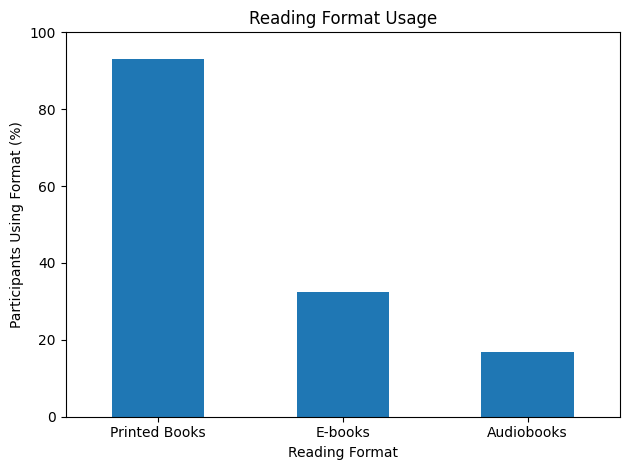

In [27]:
format_usage.plot(kind="bar")

plt.title("Reading Format Usage")
plt.xlabel("Reading Format")
plt.ylabel("Participants Using Format (%)")
plt.xticks(rotation=0)
plt.ylim(0,100)
plt.tight_layout()

plt.show()

### Finding 
Printed books were the most common reading format, used by 93.1% of participants with valid responses.
E-books were used by 32.4% of participants and audiobooks were the least common format with 16.9% usage. 
Because participants could use more than one format, these percentages don't add up to 100%. Overall, the results show that print remained the dominant format, while digital and audio formats were used by smaller percentages of readers.

## Education and Reading Volume
To see whether reading volume differs across education levels, I compared the median number of books read for each education group.
Median value are used because the books-read distribution is strongly right-skewed and contains a group of very high-volume readers.

In [28]:
education_df = df[
    df.education.notna() & 
    (df.education != "Don't know")
].copy()

In [29]:
education_order = [
    "High school incomplete",
    "High school graduate",
    "Technical, trade or vocational school AFTER high school",
    "Some college, no 4-year degree",
    "College graduate",
    "Post-graduate training/professional school after college"
]

In [30]:
education_median = (
    education_df
    .groupby("education")["books_read"]
    .median()
    .reindex(education_order)
)

education_median

education
High school incomplete                                       5.0
High school graduate                                         4.0
Technical, trade or vocational school AFTER high school      6.0
Some college, no 4-year degree                               7.0
College graduate                                            10.0
Post-graduate training/professional school after college    12.0
Name: books_read, dtype: float64

In [32]:
education_df["education"].value_counts().reindex(education_order)

education
High school incomplete                                      263
High school graduate                                        688
Technical, trade or vocational school AFTER high school      66
Some college, no 4-year degree                              651
College graduate                                            596
Post-graduate training/professional school after college    501
Name: count, dtype: int64

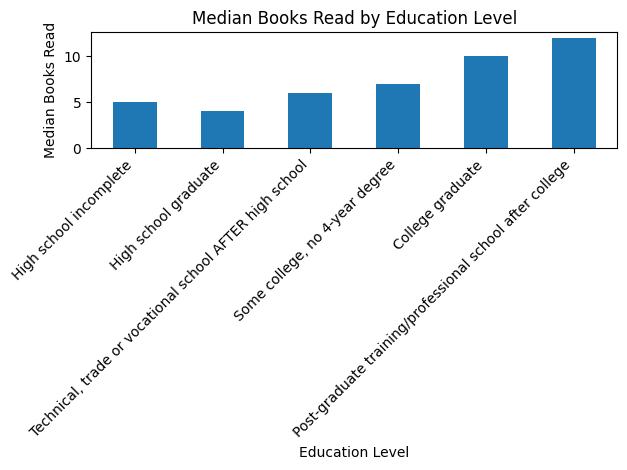

In [31]:
education_median.plot(kind="bar")

plt.title("Median Books Read by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Median Books Read")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Finding
Reading volume generally increased with education level.
Participants with a high school education or less had median books read at 4-5, while those with some college or technical training had medians of 6-7 books.
College graduates had a median of 10 books, and participants with post-graduate or professional education had teh hightest median number of books read at 12.
Although the pattern is not perfectly linear, the overall trend suggests that higher education levels are associated with higher reading volume in the dataset.
The technical/trade/vocational school group was much smaller than the others, with only 66 participants, so that result may be less representative than the other education groups